In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

df = pd.read_excel("/home/cristiancrr/CCC-ML-Project/Chagas_DB_3_Cleaning_me.xlsx")

df.columns = (df.columns.astype(str).str.strip().str.replace("\n", " ", regex=False).str.replace("  ", " ", regex=False))

TIME_COL  = "tiempo sobrevida"      
EVENT_COL = "mortalidad seguimiento"     

In [4]:
df.head()

,sexo,Edad al ingreso,Tipo de Seguridad Social,escolaridad,Estado civil,area de residencia,Frecuencia cardiaca,Presión diastólica cardíaca,Presión sistólica cardíaca,PESO (Kg),...,Glucosa,Fecha de egreso,estancia hospitalaria,mortalidad seguimiento,tiempo sobrevida,mort 2años,Traplante Cardíaco,Enfermedad Cerebrovascular,Asistencia Ventricular,descenlace cardiovascular
0,1,72.862616,0,0,0,1,59,68,101,60.0,...,NaN,2025-06-16,7,0,137.0,0.0,0,0,0,0
1,1,86.338259,0,0,0,1,67,85,133,63.0,...,152.3,2022-12-05,5,0,1059.0,0.0,0,0,0,0
2,1,83.325123,0,0,0,1,48,95,130,63.0,...,NaN,2022-08-16,8,1,377.0,1.0,0,0,0,0
3,1,82.337165,0,0,0,1,140,74,132,85.0,...,NaN,2023-06-06,3,0,874.0,0.0,0,0,0,0
4,1,70.618500,0,0,1,1,68,65,102,54.0,...,97.0,2024-03-12,48,0,639.0,0.0,0,0,0,0


Observaciones totales: 815


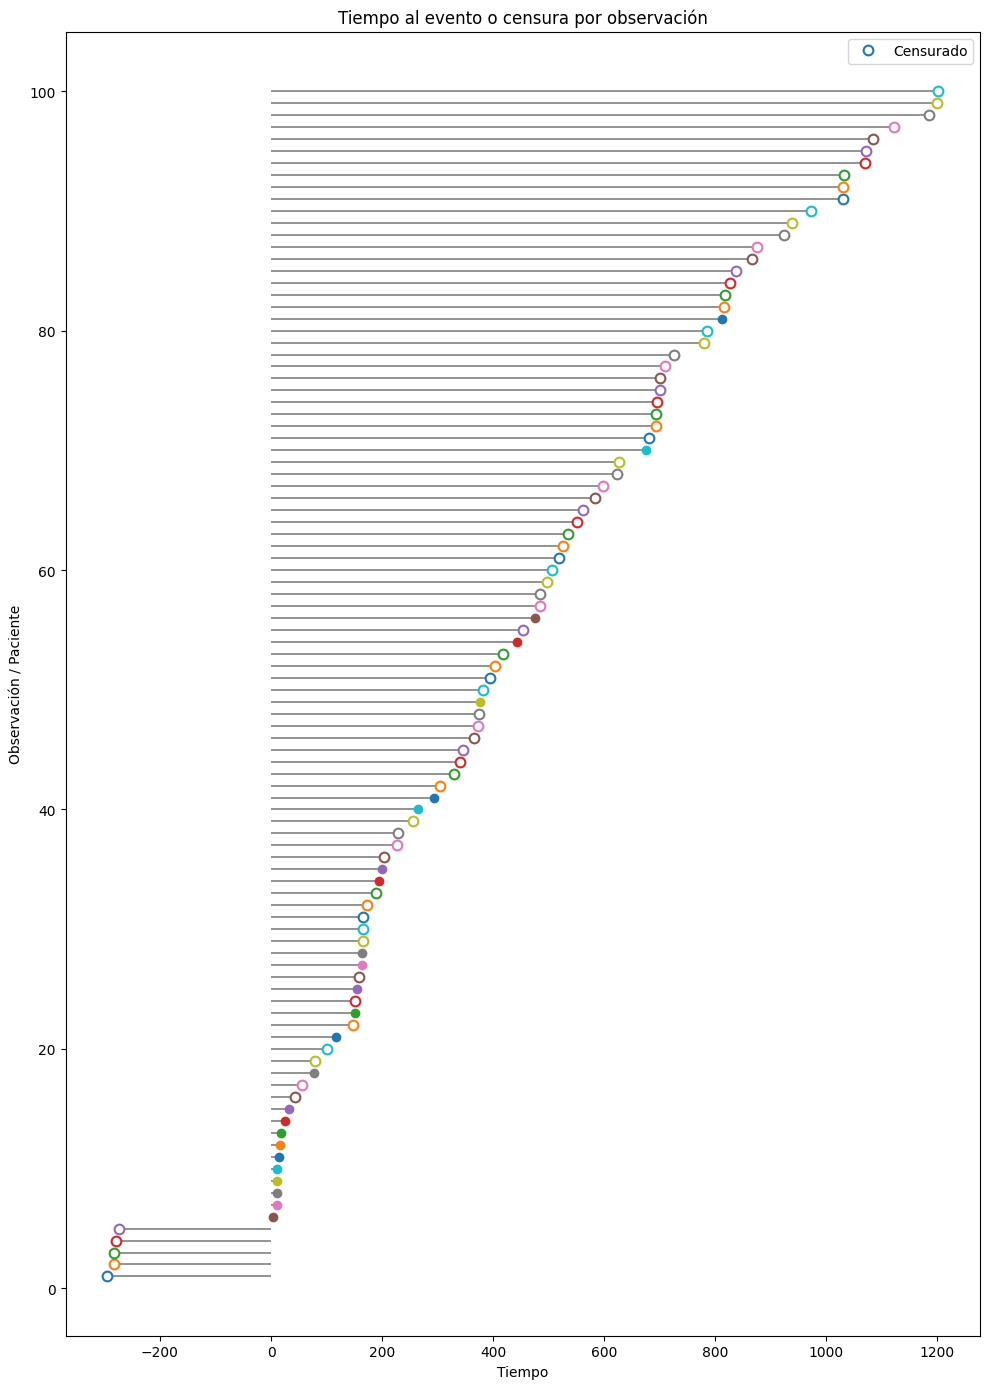

In [ ]:
# Seleccionar columnas
df_plot = df[["tiempo sobrevida", "mortalidad seguimiento"]].copy()

# Renombrar para trabajar más cómodo
df_plot.columns = ["time", "event"]

# Limpiar faltantes
df_plot = df_plot.dropna(subset=["time", "event"])

# Asegurar tipos
df_plot["time"] = pd.to_numeric(df_plot["time"], errors="coerce")
df_plot["event"] = pd.to_numeric(df_plot["event"], errors="coerce")

df_plot = df_plot.dropna(subset=["time", "event"])

# Ordenar por tiempo para que el gráfico quede más limpio
df_plot = df_plot.sort_values("time").reset_index(drop=True)
print(f"Observaciones totales: {len(df_plot)}")

# Crear posición vertical para cada observación
df_plot_small = df_plot.sample(100, random_state=42).sort_values("time").reset_index(drop=True)
df_plot_small["y"] = np.arange(1, len(df_plot_small) + 1)
#df_plot["y"] = np.arange(1, len(df_plot) + 1)

# Graficar
fig, ax = plt.subplots(figsize=(10, 14))

for _, row in df_plot_small.iterrows():
    # línea horizontal desde 0 hasta el tiempo observado
    ax.hlines(y=row["y"], xmin=0, xmax=row["time"], color="gray", linewidth=1.2)

    # punto según evento o censura
    if row["event"] == 1:
        ax.plot(row["time"], row["y"], "o", markersize=6, label="Evento" if row["y"] == 1 else "")
    else:
        ax.plot(
            row["time"], row["y"],
            marker="o",
            markersize=7,
            markerfacecolor="white",
            markeredgewidth=1.5,
            linestyle="None",
            label="Censurado" if row["y"] == 1 else ""
        )

ax.set_xlabel("Tiempo")
ax.set_ylabel("Observación / Paciente")
ax.set_title("Tiempo al evento o censura por observación")

# Evitar duplicados en la leyenda
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys())

plt.tight_layout()
plt.show()

In [14]:
neg = df[df[TIME_COL] < 0]
print("Casos con tiempo negativo:", len(neg))
print(neg[[TIME_COL, EVENT_COL]].head())

Casos con tiempo negativo: 45
     tiempo sobrevida  mortalidad seguimiento
81             -333.0                       0
133            -321.0                       0
164            -278.0                       0
193            -354.0                       0
199            -280.0                       0


Observaciones incluidas en el gráfico: 770


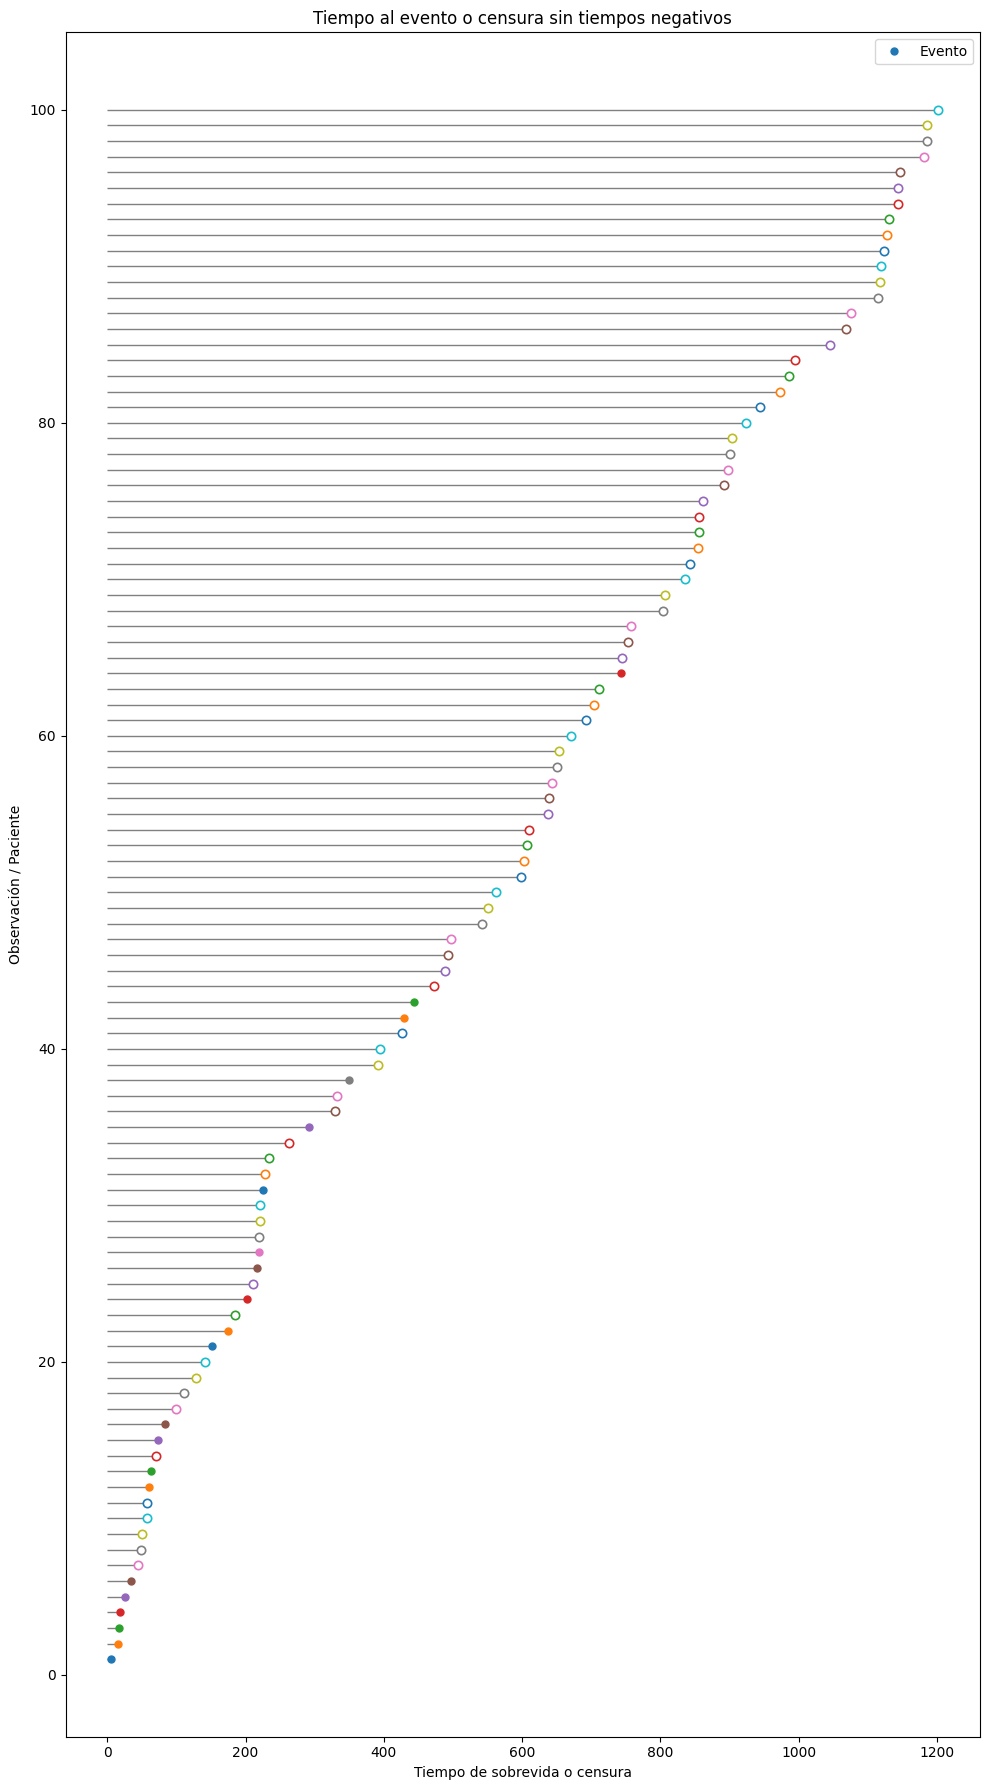

In [16]:
# Excluir tiempos de sobrevida negativos y volver a graficar
df_plot_clean = df[[TIME_COL, EVENT_COL]].copy()
df_plot_clean.columns = ["time", "event"]

df_plot_clean["time"] = pd.to_numeric(df_plot_clean["time"], errors="coerce")
df_plot_clean["event"] = pd.to_numeric(df_plot_clean["event"], errors="coerce")

df_plot_clean = df_plot_clean.dropna(subset=["time", "event"])
df_plot_clean = df_plot_clean[df_plot_clean["time"] >= 0].sort_values("time").reset_index(drop=True)
df_plot_clean["y"] = np.arange(1, len(df_plot_clean) + 1)
df_plot_small = df_plot_clean.sample(100, random_state=42).sort_values("time").reset_index(drop=True)
df_plot_small["y"] = np.arange(1, len(df_plot_small) + 1)

print(f"Observaciones incluidas en el gráfico: {len(df_plot_clean)}")

fig_height = min(max(8, len(df_plot_clean) * 0.12), 18)
fig, ax = plt.subplots(figsize=(10, fig_height))

for _, row in df_plot_small.iterrows():
    ax.hlines(y=row["y"], xmin=0, xmax=row["time"], color="gray", linewidth=1.0)

    if row["event"] == 1:
        ax.plot(row["time"], row["y"], "o", markersize=5, label="Evento" if row["y"] == 1 else "")
    else:
        ax.plot(
            row["time"], row["y"],
            marker="o",
            markersize=6,
            markerfacecolor="white",
            markeredgewidth=1.2,
            linestyle="None",
            label="Censurado" if row["y"] == 1 else ""
        )

ax.set_xlabel("Tiempo de sobrevida o censura")
ax.set_ylabel("Observación / Paciente")
ax.set_title("Tiempo al evento o censura sin tiempos negativos")

handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys())

plt.tight_layout()
plt.show()

In [17]:
# Contar eventos con corte en 600 dias
df_eventos_600 = df[[TIME_COL, EVENT_COL]].copy()
df_eventos_600.columns = ["time", "event"]

df_eventos_600["time"] = pd.to_numeric(df_eventos_600["time"], errors="coerce")
df_eventos_600["event"] = pd.to_numeric(df_eventos_600["event"], errors="coerce")

df_eventos_600 = df_eventos_600.dropna(subset=["time", "event"])
df_eventos_600 = df_eventos_600[df_eventos_600["time"] >= 0]

eventos_mayor_600 = ((df_eventos_600["time"] > 600) & (df_eventos_600["event"] == 1)).sum()
eventos_menor_600 = ((df_eventos_600["time"] < 600) & (df_eventos_600["event"] == 1)).sum()
eventos_igual_600 = ((df_eventos_600["time"] == 600) & (df_eventos_600["event"] == 1)).sum()

print(f"Personas con tiempo de observacion > 600 dias y con evento: {eventos_mayor_600}")
print(f"Personas con tiempo de observacion < 600 dias y con evento: {eventos_menor_600}")
print(f"Personas con tiempo de observacion = 600 dias y con evento: {eventos_igual_600}")

Personas con tiempo de observacion > 600 dias y con evento: 21
Personas con tiempo de observacion < 600 dias y con evento: 163
Personas con tiempo de observacion = 600 dias y con evento: 0


Observaciones con tiempo de sobrevida >= 0: 770
Total con evento: 184
Total censuradas: 586

Tabla por grupo de tiempo y estado:


estado,Censurado,Evento
grupo_tiempo,,
<= 600 dias,261,163
> 600 dias,325,21


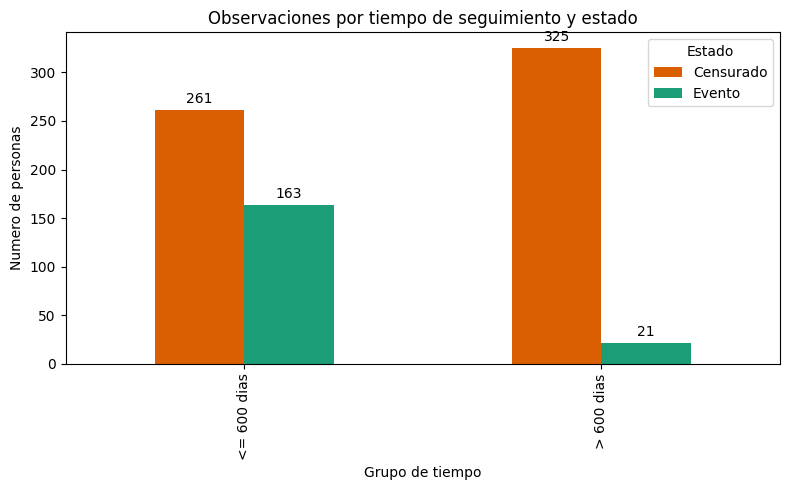

In [18]:
# Resumen completo del dataset con tiempo >= 0 y diagrama de barras
df_resumen = df[[TIME_COL, EVENT_COL]].copy()
df_resumen.columns = ["time", "event"]

df_resumen["time"] = pd.to_numeric(df_resumen["time"], errors="coerce")
df_resumen["event"] = pd.to_numeric(df_resumen["event"], errors="coerce")

df_resumen = df_resumen.dropna(subset=["time", "event"])
df_resumen = df_resumen[df_resumen["time"] >= 0].copy()

df_resumen["grupo_tiempo"] = np.where(df_resumen["time"] > 600, "> 600 dias", "<= 600 dias")
df_resumen["estado"] = np.where(df_resumen["event"] == 1, "Evento", "Censurado")

tabla_resumen = pd.crosstab(df_resumen["grupo_tiempo"], df_resumen["estado"])
tabla_resumen = tabla_resumen.reindex(["<= 600 dias", "> 600 dias"], fill_value=0)

total_obs = len(df_resumen)
total_eventos = (df_resumen["event"] == 1).sum()
total_censurados = (df_resumen["event"] == 0).sum()

print(f"Observaciones con tiempo de sobrevida >= 0: {total_obs}")
print(f"Total con evento: {total_eventos}")
print(f"Total censuradas: {total_censurados}")
print("\nTabla por grupo de tiempo y estado:")
display(tabla_resumen)

ax = tabla_resumen.plot(kind="bar", figsize=(8, 5), color=["#d95f02", "#1b9e77"])
ax.set_title("Observaciones por tiempo de seguimiento y estado")
ax.set_xlabel("Grupo de tiempo")
ax.set_ylabel("Numero de personas")
ax.legend(title="Estado")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

Observaciones incluidas en Kaplan-Meier global: 770
event
0    586
1    184
Name: count, dtype: int64


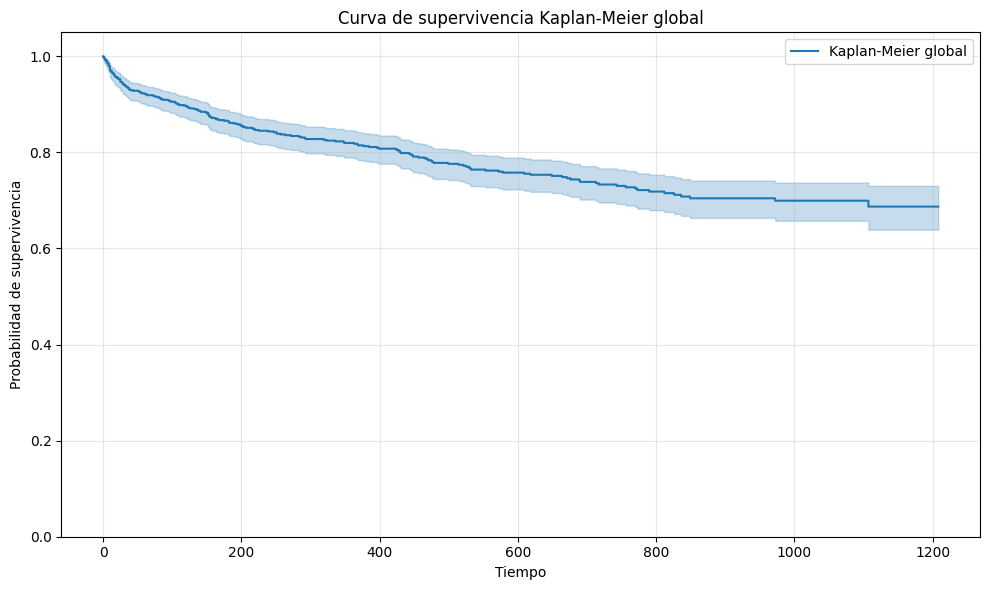

In [22]:
# Curva Kaplan-Meier global
from lifelines import KaplanMeierFitter

df_km_global = df[[TIME_COL, EVENT_COL]].copy()
df_km_global.columns = ["time", "event"]

df_km_global["time"] = pd.to_numeric(df_km_global["time"], errors="coerce")
df_km_global["event"] = pd.to_numeric(df_km_global["event"], errors="coerce")

df_km_global = df_km_global.dropna(subset=["time", "event"])
df_km_global = df_km_global[df_km_global["time"] >= 0].copy()
df_km_global["event"] = df_km_global["event"].astype(int)

print(f"Observaciones incluidas en Kaplan-Meier global: {len(df_km_global)}")
print(df_km_global["event"].value_counts())

kmf = KaplanMeierFitter()
kmf.fit(
    durations=df_km_global["time"],
    event_observed=df_km_global["event"],
    label="Kaplan-Meier global"
)

ax = kmf.plot_survival_function(ci_show=True, figsize=(10, 6))
ax.set_title("Curva de supervivencia Kaplan-Meier global")
ax.set_xlabel("Tiempo")
ax.set_ylabel("Probabilidad de supervivencia")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

     time  event  sexo
0   137.0      0     1
1  1059.0      0     1
2   377.0      1     1
3   874.0      0     1
4   639.0      0     1
sexo
1    464
0    306
Name: count, dtype: int64
event
0    586
1    184
Name: count, dtype: int64


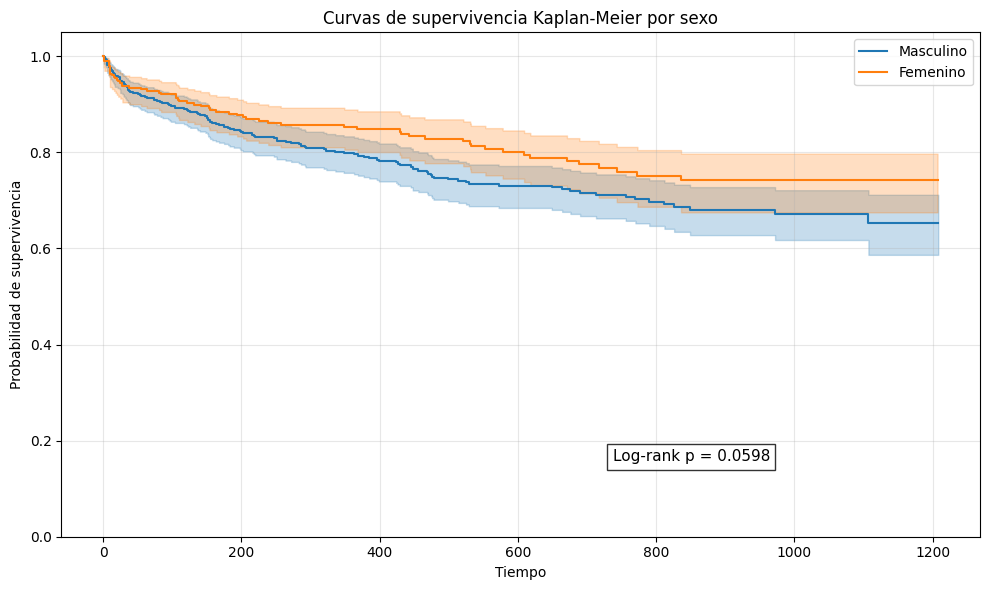

   test_statistic         p  -log2(p)
0        3.542628  0.059811  4.063455


In [24]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

SEX_COL = "sexo"
cols = [TIME_COL, EVENT_COL, SEX_COL]
df_km = df[cols].copy()

df_km.columns = ["time", "event", "sexo"]

df_km["time"] = pd.to_numeric(df_km["time"], errors="coerce")
df_km["event"] = pd.to_numeric(df_km["event"], errors="coerce")
df_km["sexo"] = pd.to_numeric(df_km["sexo"], errors="coerce")

df_km = df_km.dropna(subset=["time", "event", "sexo"])

# Mantener solo sexo 0 y 1
df_km = df_km[df_km["sexo"].isin([0, 1])]

# Quitar tiempos negativos si existen
df_km = df_km[df_km["time"] >= 0]

# Asegurar enteros
df_km["event"] = df_km["event"].astype(int)
df_km["sexo"] = df_km["sexo"].astype(int)

print(df_km.head())
print(df_km["sexo"].value_counts())
print(df_km["event"].value_counts())

# =========================
# 3. Separar grupos
# =========================
df_m = df_km[df_km["sexo"] == 1]
df_f = df_km[df_km["sexo"] == 0]

results = logrank_test(
    df_m["time"],
    df_f["time"],
    event_observed_A=df_m["event"],
    event_observed_B=df_f["event"]
)

# =========================
# 4. Ajustar Kaplan-Meier
# =========================
kmf_m = KaplanMeierFitter()
kmf_f = KaplanMeierFitter()

plt.figure(figsize=(10, 6))

kmf_m.fit(
    durations=df_m["time"],
    event_observed=df_m["event"],
    label="Masculino"
)
ax = kmf_m.plot_survival_function(ci_show=True)

kmf_f.fit(
    durations=df_f["time"],
    event_observed=df_f["event"],
    label="Femenino"
)
kmf_f.plot_survival_function(ci_show=True, ax=ax)

# 5. Personalizar
# =========================
plt.title("Curvas de supervivencia Kaplan-Meier por sexo")
plt.xlabel("Tiempo")
plt.ylabel("Probabilidad de supervivencia")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)

plt.text(
    0.60, 0.15,
    f"Log-rank p = {results.p_value:.4f}",
    transform=ax.transAxes,
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()

print(results.summary)